In [1]:
import json

laser_csk_file = "results.json" # <-- path to JSON file
laser_csk_data = {}
# Load the data from the JSON file
with open(laser_csk_file, 'r') as file:
    laser_csk_data = json.load(file)

filtered_data = {} # Dictionary to hold the filtered data without Nan values
for key, value in laser_csk_data.items():
    hole_number = key.split('_')[-1]
    left_total_depth = value.get('right_total_depth')
    right_total_depth = value.get('left_total_depth')
    if left_total_depth is not None and right_total_depth is not None:
        filtered_data[hole_number] = {
            'left': left_total_depth,
            'right': right_total_depth
        }
        
# save the filtered data to a CSV file with the following format:
# row 1: hole_number 1l, hole_number 1r, hole_number 2l, hole_number 2r, hole_number 3l, hole_number 3r, ... 
# row 2: left_total_depth,right_total_depth, left_total_depth,right_total_depth, left_total_depth,right_total_depth, ...
import csv
csv_file = 'filtered_laser_csk_data2.csv'
with open('filtered_laser_csk_data2.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    # Write the header row
    header = []
    for hole_number in filtered_data.keys():
        header.append(hole_number+'l')
        header.append(hole_number+'r')
    writer.writerow(header)
    # Write the data row
    data_row = []
    for depths in filtered_data.values():
        data_row.append(depths['left'])
        data_row.append(depths['right'])
    writer.writerow(data_row)
print("Filtered data saved to", csv_file)


Filtered data saved to filtered_laser_csk_data2.csv


RMSE: 0.0211
Mean Error: -0.0193
Median Absolute Error: 0.0208
Standard Deviation of Errors: 0.0085


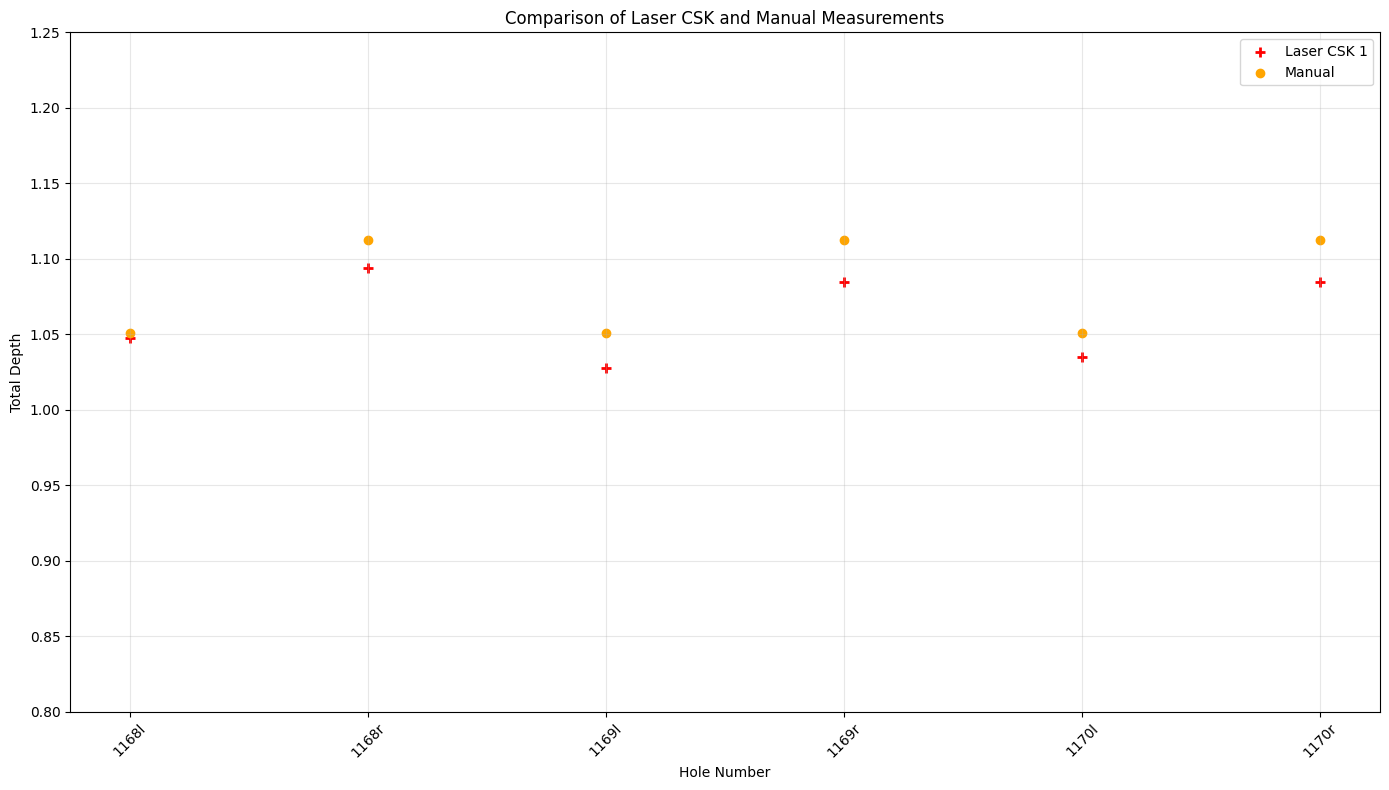

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

manual_file = 'manual.csv' # <-- path to manual csv file
manual_data = pd.read_csv(manual_file, header=None)
laser_file = 'filtered_laser_csk_data2.csv' # <-- path to laser csv file
laser_data = pd.read_csv(laser_file, header=None)

manual_holes = manual_data.iloc[0, :].astype(str).tolist()  # Get hole numbers from manual data

laser_holes = laser_data.iloc[0, :].astype(str).tolist()  # Get hole numbers from laser data

ordered_common_holes = []
for hole in manual_holes:
    if hole in laser_holes:
        ordered_common_holes.append(hole)
# print("Ordered common holes:", ordered_common_holes)

# plot scatter for the values of the common holes
laser_values = []
manual_values = []
for hole in ordered_common_holes:
    index = laser_holes.index(hole)
    laser_values.append(float(laser_data.iloc[1, index]))
    index = manual_holes.index(hole)
    manual_values.append(float(manual_data.iloc[1, index]))

plt.figure(figsize=(14, 8))
plt.scatter(ordered_common_holes, laser_values, label='Laser CSK 1', marker='+', s=50, linewidths=2, color='red')
plt.scatter(ordered_common_holes, manual_values, label='Manual', color='orange')
plt.xlabel('Hole Number')
plt.ylabel('Total Depth')
plt.title('Comparison of Laser CSK and Manual Measurements')
plt.xticks(rotation=45)
plt.legend()
plt.yticks(np.arange(0.8, 1.3, 0.05))
plt.grid(alpha=0.3)
plt.tight_layout()

# calculate rmse
laser_array1 = np.array(laser_values)
manual_array = np.array(manual_values)

error = laser_array1 - manual_array

# rmse
rmse = np.sqrt(np.mean(error ** 2))
print(f"RMSE: {rmse:.4f}")

# mean error
mean_error = np.mean(error)
print(f"Mean Error: {mean_error:.4f}")

# median error
median_error = np.median(np.abs(error))
print(f"Median Absolute Error: {median_error:.4f}")

# calculate the standard deviation of the errors over all laser measurements by calcualting the variance of each hole and then taking the square root of the mean of the variances
std_dev_errors = np.sqrt(np.mean(np.var(error)))
print(f"Standard Deviation of Errors: {std_dev_errors:.4f}")

In [3]:
# I want you to take a random sample of 50 percent, calculate the bias accordingly, then re-do the evaluation after bias removal
np.random.seed(42)  # For reproducibility
sample_size = len(error) // 2
sample_indices = np.random.choice(len(error), size=sample_size, replace=False)
sample_errors = error[sample_indices]
bias = np.mean(sample_errors)
print(f"Calculated Bias from Sample: {bias:.4f}")
corrected_laser_array = laser_array1 - bias
corrected_error = corrected_laser_array - manual_array
# corrected rmse
corrected_rmse = np.sqrt(np.mean(corrected_error ** 2))
print(f"Corrected RMSE after Bias Removal: {corrected_rmse:.4f}")
# corrected mean error
corrected_mean_error = np.mean(corrected_error)
print(f"Corrected Mean Error after Bias Removal: {corrected_mean_error:.4f}")   

Calculated Bias from Sample: -0.0165
Corrected RMSE after Bias Removal: 0.0090
Corrected Mean Error after Bias Removal: -0.0028
